# `frust_vary_T.ipynb`: frustration by temperature

In [ ]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from scipy.stats import ttest_ind

from utils.energies import *
from utils.modelIO import *

initialize

In [9]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
RAND_GRN_PATH = Path('results/eml/random_networks.npy')
BIO_SIM_PATH = Path('results/eml/bio_vary_T/')
RAND_SIM_PATH = Path('results/eml/rand_vary_T/')
FIG_SAVE_PATH = Path('figs/eml/')

bio_grn, gids, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
rgrns = jnp.load(RAND_GRN_PATH)[:1000]
temperatures = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

load final states

In [7]:
def load_bio_T(T):
    path = BIO_SIM_PATH.joinpath('bio_T_{:.0e}_xs.npy'.format(T))
    return jnp.load(path)[:, -1]
bio_xs = jnp.array([load_bio_T(T) for T in temperatures])

def load_rand_T(T):
    path = RAND_SIM_PATH.joinpath('rand_T_{:.0e}_xs.npy'.format(T))
    return jnp.load(path)[:, -1]
rand_xs = jnp.array([load_rand_T(T) for T in temperatures])

vmap function for biological GRN

In [11]:
def bio_frust_instance(grn_state):
    return get_pct_frustration(bio_grn, grn_state, N)
bio_frust_vmap = jax.vmap(jax.vmap(bio_frust_instance))
bio_frust = bio_frust_vmap(bio_xs)

vmap function for random networks

In [13]:
def rand_frust_instance(rand_pair):
    rgrn, grn_state = rand_pair
    return get_pct_frustration(rgrn, grn_state, N)
rand_frust_vmap = jax.vmap(rand_frust_instance)
rand_frust = jnp.array([rand_frust_vmap((rgrns, xs)) for xs in rand_xs])

make violin plots

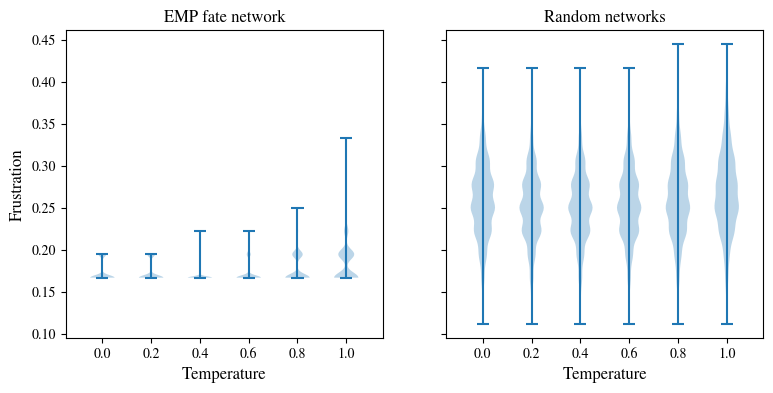

<Figure size 640x480 with 0 Axes>

In [18]:
def set_axis_style(ax, labels):
    ax.set_xticks(jnp.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Temperature', fontsize=12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
ax1.set_title('EMP fate network', fontsize=12)
ax1.set_ylabel('Frustration', fontsize=12)
ax2.set_title('Random networks', fontsize=12)
ax1.violinplot(bio_frust.T)
ax2.violinplot(rand_frust.T)
for ax in [ax1, ax2]:
    set_axis_style(ax, temperatures)
plt.show()
plt.savefig(FIG_SAVE_PATH.joinpath('frust_vary_T.pdf'), bbox_inches='tight')

In [20]:
ttest_results = [ttest_ind(bio_frust[i], rand_frust[i]) for i in range(len(temperatures))]

In [21]:
ttest_results

[TtestResult(statistic=np.float64(-58.213077885141104), pvalue=np.float64(0.0), df=np.float64(1998.0)),
 TtestResult(statistic=np.float64(-56.049610993517696), pvalue=np.float64(0.0), df=np.float64(1998.0)),
 TtestResult(statistic=np.float64(-61.37684494001434), pvalue=np.float64(0.0), df=np.float64(1998.0)),
 TtestResult(statistic=np.float64(-58.40435617540658), pvalue=np.float64(0.0), df=np.float64(1998.0)),
 TtestResult(statistic=np.float64(-52.12059860345292), pvalue=np.float64(0.0), df=np.float64(1998.0)),
 TtestResult(statistic=np.float64(-47.476778735007805), pvalue=np.float64(0.0), df=np.float64(1998.0))]